#**CHAPTER 9.GRAPH NEURAL NETWORKS**
---

##REFERENCE

https://chatgpt.com/share/69a99eeb-f920-8012-85fc-26d4b406ca6e

##0.CONTEXT

*Introduction*

Chapter 9 introduces a structural idea that is easy to say and surprisingly hard to internalize until you see it operate: sometimes the “data” is not a collection of independent rows, but a *system of entities connected by relationships*. In a graph setting, a node’s meaning is not determined only by its own features; it is also shaped by the states of its neighbors and, through them, by the broader network. A graph neural network (GNN) exists to operationalize that dependency: it learns by repeatedly *propagating information along edges* (message passing), so that each node’s internal representation becomes a blend of “what I am” and “who I touch.”

The notebook implements this idea using a synthetic “credit contagion” network. Each node represents an entity such as a borrower or firm. Each edge represents some exposure or dependency channel: shared counterparties, direct bilateral exposure, supply chain dependence, funding links, or any relational pathway through which distress could propagate. The learning task is node classification: predict whether a node is “healthy” (0) or “default-like” (1). Importantly, the labels are not arbitrary. They are engineered to depend on two components at once: (1) node-level drivers (systemic and idiosyncratic features), and (2) a contagion term that increases risk when a node’s neighbors show distress. That second term is the pedagogical fulcrum: it makes the ground truth partially *relational*. If you strip away the graph structure, the model is forced to pretend nodes are independent, and it should predict worse.

Because this is a mechanics-first laboratory, everything is generated inside the notebook with determinism enforced. This gives you a controlled environment where you can see exactly what the graph contributes. You can separate “learning from features” from “learning from topology,” and you can test which behaviors arise from message passing rather than from hidden confounders in the data. In practical terms, the notebook makes the GNN machinery tangible in three ways:

First, it makes adjacency normalization explicit. GNNs usually do not pass raw neighbor sums. They pass a normalized blend (often with self-loops) so that each node receives a stable-scale average of its neighborhood rather than an unbounded degree-dependent accumulation. You will see this constructed as a dense matrix for clarity, even though real systems use sparse representations.

Second, it enforces the training vs inference distinction in a graph context. During training, parameters are learned via gradient descent by minimizing a loss on a training mask of nodes (while the graph provides the relational context). During evaluation, you freeze the parameters and measure generalization on held-out nodes. During inference demonstration, you generate a *new synthetic node*, attach it to the existing network, and predict its default probability. This reveals a key conceptual difference from earlier chapters: “a new input” can mean “a new node inserted into a relational context,” not just “a new row vector.”

Third, it uses visualization not as decoration but as interpretability scaffolding. You will visualize node labels on the graph, view how a local shock signal diffuses across neighbors over propagation steps, and compare the distribution of predicted probabilities under an ablation that removes message passing. These are the mechanical pictures that make GNNs click: message passing is not mystical; it is repeated neighborhood mixing plus learnable transforms.

In the ML & AI 101 progression, Chapter 9 adds a new inductive bias: relational structure. Earlier chapters introduced geometry (KNN), nonlinear approximation (dense nets), spatial locality (CNN), temporal memory (RNN/LSTM), global contextual routing (Transformer attention), and generative mechanisms (GAN and diffusion). Now the central assumption is: “the world is a graph, and prediction requires neighborhood context.” This naturally sets up Chapter 10 (Genetic Algorithms), because once you see how strongly performance can depend on design choices (hidden size, number of message passing layers, normalization, stress-test robustness), it becomes natural to treat architecture selection itself as something you can optimize with search procedures rather than hand-tune.

##1.LIBRARIES AND ENVIRONMENT

**Cell 1 — Setup, Determinism, Plotting, and Training Helpers**

Cell 1 establishes the shared mechanical infrastructure that every chapter notebook relies on, but here it is especially important because graph experiments can easily become “unclear” if visualization and reproducibility are not enforced from the start.

The first role of Cell 1 is determinism. The notebook sets seeds for Python’s random module, NumPy, and PyTorch (including CUDA) so that the graph structure, synthetic features, labels, training split, and training dynamics are repeatable. This matters for pedagogy because you want the student to see the same loss curve and roughly the same accuracy when they rerun the notebook; otherwise, they might attribute random variation to the model’s conceptual behavior.

The second role is device selection. The get_device() function chooses GPU when available and CPU otherwise. This keeps the notebook runnable in standard Colab environments while still allowing acceleration when possible. Mechanically, the student learns that device selection is a runtime property, not part of the model definition.

The third role is plotting utilities. Graphs are not naturally “plottable” like 2D points, so the notebook includes graph plotting and a propagation plotting helper that visualizes node values across multiple steps. The plotting utilities are intentionally explicit: each creates figures, labels axes, sets titles, and calls plt.show(). This is not a cosmetic requirement; it makes the notebook execution self-contained and consistent.

The fourth role is training utilities. Even though the GNN training loop uses a masked loss (because we train on a subset of nodes), the notebook keeps a standard structure: a function that runs epochs, prints progress, stores loss history, and returns it. This cell is therefore the “operational contract” that keeps the later cells focused on the model’s mechanics rather than boilerplate.

In [1]:
# ===============================
# CELL 1
# ===============================
import os
import json
import math
import random
from dataclasses import dataclass
from typing import Tuple, Dict, List, Optional

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Determinism
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()

# Unified plotting style
plt.style.use("seaborn-v0_8-darkgrid")

# -------------------------------
# Plotting utilities (MANDATORY)
# -------------------------------
def plot_loss_curve(losses, title="Training Loss Curve"):
    fig = plt.figure(figsize=(7, 4))
    ax = fig.add_subplot(111)
    ax.plot(np.arange(len(losses)), losses)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    plt.show()

def plot_2d_data(X, y, title="2D Data"):
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111)
    Xn = np.asarray(X)
    yn = np.asarray(y).astype(int)
    ax.scatter(Xn[:, 0], Xn[:, 1], c=yn, s=18)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    plt.show()

def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    # For general compatibility: only meaningful for 2D features.
    model.eval()
    Xn = np.asarray(X)
    yn = np.asarray(y).astype(int)
    if Xn.ndim != 2 or Xn.shape[1] != 2:
        fig = plt.figure(figsize=(6, 4))
        ax = fig.add_subplot(111)
        ax.set_title(title + " (skipped: X not 2D)")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        plt.show()
        return

    x_min, x_max = Xn[:, 0].min() - 0.5, Xn[:, 0].max() + 0.5
    y_min, y_max = Xn[:, 1].min() - 0.5, Xn[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)

    with torch.no_grad():
        logits = model(torch.from_numpy(grid).to(DEVICE))
        probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
    zz = probs.reshape(xx.shape)

    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111)
    cs = ax.contourf(xx, yy, zz, levels=25, alpha=0.85)
    ax.scatter(Xn[:, 0], Xn[:, 1], c=yn, s=18, edgecolors="k", linewidths=0.2)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    fig.colorbar(cs, ax=ax, label="P(class=1)")
    plt.show()

def show_image(img, title="Image"):
    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111)
    arr = np.asarray(img)
    if arr.ndim == 2:
        ax.imshow(arr, cmap="gray")
    else:
        ax.imshow(arr)
    ax.set_title(title)
    ax.set_xlabel("width")
    ax.set_ylabel("height")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

def show_image_grid(images, labels=None, title="Image Grid", max_n=16):
    imgs = list(images)
    n = min(len(imgs), max_n)
    cols = int(math.ceil(math.sqrt(n)))
    rows = int(math.ceil(n / cols))

    fig = plt.figure(figsize=(3 * cols, 3 * rows))
    for i in range(n):
        ax = fig.add_subplot(rows, cols, i + 1)
        arr = np.asarray(imgs[i])
        if arr.ndim == 2:
            ax.imshow(arr, cmap="gray")
        else:
            ax.imshow(arr)
        if labels is not None:
            ax.set_title(str(labels[i]))
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(title)
    plt.show()

def plot_histograms(real, fake, title="Real vs Fake Histogram"):
    real = np.asarray(real).ravel()
    fake = np.asarray(fake).ravel()
    fig = plt.figure(figsize=(7, 4))
    ax = fig.add_subplot(111)
    ax.hist(real, bins=40, alpha=0.65, label="Real", density=True)
    ax.hist(fake, bins=40, alpha=0.65, label="Fake", density=True)
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()
    plt.show()

def plot_attention(matrix, title="Attention Matrix"):
    M = np.asarray(matrix)
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111)
    im = ax.imshow(M, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Source index")
    ax.set_ylabel("Target index")
    fig.colorbar(im, ax=ax)
    plt.show()

def plot_graph(G, node_values=None, title="Graph"):
    # Implemented without networkx dependency (chapter allows it only for graph chapter,
    # but we keep this function generic and purely matplotlib).
    # G: dict with keys "edges" (E,2) int, "num_nodes" int.
    edges = np.asarray(G["edges"], dtype=np.int64)
    n = int(G["num_nodes"])
    # Simple circular layout
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    pos = np.stack([np.cos(angles), np.sin(angles)], axis=1)

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)
    # Edges
    for (u, v) in edges:
        ax.plot([pos[u, 0], pos[v, 0]], [pos[u, 1], pos[v, 1]], linewidth=1.0, alpha=0.6)
    # Nodes
    if node_values is None:
        ax.scatter(pos[:, 0], pos[:, 1], s=80)
    else:
        vals = np.asarray(node_values).astype(np.float32)
        sc = ax.scatter(pos[:, 0], pos[:, 1], s=90, c=vals)
        fig.colorbar(sc, ax=ax, label="node_value")
    for i in range(n):
        ax.text(pos[i, 0], pos[i, 1], f"{i}", ha="center", va="center", fontsize=9, color="black")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

def plot_graph_propagation(G, node_values_steps, title="GNN Propagation (Steps)"):
    # Visualize node values over multiple propagation steps
    steps = list(node_values_steps)
    T = len(steps)
    cols = min(T, 4)
    rows = int(math.ceil(T / cols))
    fig = plt.figure(figsize=(6 * cols, 6 * rows))
    edges = np.asarray(G["edges"], dtype=np.int64)
    n = int(G["num_nodes"])
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    pos = np.stack([np.cos(angles), np.sin(angles)], axis=1)

    for t in range(T):
        ax = fig.add_subplot(rows, cols, t + 1)
        for (u, v) in edges:
            ax.plot([pos[u, 0], pos[v, 0]], [pos[u, 1], pos[v, 1]], linewidth=1.0, alpha=0.6)
        vals = np.asarray(steps[t]).astype(np.float32)
        sc = ax.scatter(pos[:, 0], pos[:, 1], s=90, c=vals)
        ax.set_title(f"Step {t}")
        ax.set_xticks([])
        ax.set_yticks([])
        for i in range(n):
            ax.text(pos[i, 0], pos[i, 1], f"{i}", ha="center", va="center", fontsize=9, color="black")
        fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    plt.show()

# --------------------------------
# PyTorch helpers (MANDATORY)
# --------------------------------
def train_loop(model, optimizer, loss_fn, X, y, epochs=100):
    model.train()
    losses = []
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad(set_to_none=True)
        logits = model(X)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(float(loss.detach().cpu().item()))
        if epoch == 1 or epoch % max(1, epochs // 10) == 0 or epoch == epochs:
            print(f"Epoch {epoch:4d}/{epochs} | loss={losses[-1]:.6f}")
    return losses

def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean().item()
    return {"accuracy": float(acc)}

def predict(model, X):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
    return preds, probs

print("Device:", DEVICE)

Device: cpu


##2.DATA GENERATOR

###2.1.OVERVIEW

**Cell 2 — Synthetic Credit Graph and Contagion Data Generators**

Cell 2 defines the synthetic data generators for the graph chapter. The point is not to generate a realistic credit dataset; the point is to generate a dataset whose underlying mechanism is simple, controllable, and explicitly relational.

First, the notebook constructs a random undirected graph with a target average degree. Edges are sampled deterministically using a fixed seed and stored as integer pairs. This produces a topology that is complex enough to show propagation effects but simple enough to visualize.

Second, the notebook builds the adjacency matrix and its normalized version. This is the “math inside message passing.” The raw adjacency A says who is connected to whom. Adding self-loops ensures that each node retains some of its own signal during propagation. Normalizing with D^{-1/2} A D^{-1/2} (implemented numerically) stabilizes scale across nodes with different degrees. Mechanically, this prevents high-degree nodes from dominating just because they have more neighbors.

Third, the notebook generates node features and labels with a contagion mechanism:
- Each node receives a small systemic feature vector (think: macro sensitivity) and additional idiosyncratic features (think: leverage, liquidity).
- A base latent risk score is formed from a linear projection plus noise.
- An initial default indicator is sampled from a probability derived from the latent score.
- Contagion is then injected: a node’s final risk is increased by the fraction of defaulted neighbors, scaled by a contagion strength.
- The final label is produced deterministically from the resulting probability to keep labels stable.

This design is deliberate: the “right answer” depends on both node attributes and neighborhood distress. That is exactly what a GNN should exploit. If a model ignores adjacency, it can still learn something from features, but it cannot fully capture the contagion term, and performance should drop under the ablation in later cells.

Finally, the generator normalizes features (standardization) and returns intermediate arrays (means, stds, neighbor default fractions). These intermediates are later used for consistent inference on a new node and for interpretability analysis that links predicted probabilities to the contagion signal.

###2.2.CODE AND IMPLEMENTATION

In [3]:
# ===============================
# CELL 2
# ===============================
def generate_credit_graph(
    n_nodes=120,
    avg_degree=4,
    seed=0
):
    """
    Deterministic synthetic credit network.
    Returns:
      - G: dict with 'edges' (E,2) int, 'num_nodes' int
    """
    rng = np.random.RandomState(seed)

    # Generate an undirected random graph with roughly avg_degree.
    # We'll create edges by sampling pairs; ensure no self-loops and no duplicates.
    target_edges = int(n_nodes * avg_degree // 2)
    edge_set = set()
    tries = 0
    max_tries = target_edges * 50

    while len(edge_set) < target_edges and tries < max_tries:
        u = int(rng.randint(0, n_nodes))
        v = int(rng.randint(0, n_nodes))
        tries += 1
        if u == v:
            continue
        a, b = (u, v) if u < v else (v, u)
        edge_set.add((a, b))

    edges = np.array(sorted(list(edge_set)), dtype=np.int64)
    G = {"edges": edges, "num_nodes": int(n_nodes)}
    return G

def build_normalized_adjacency(G, add_self_loops=True):
    """
    Build symmetric normalized adjacency:  D^{-1/2} (A + I) D^{-1/2}
    Returns dense numpy float32 matrix for pedagogical clarity.
    """
    n = int(G["num_nodes"])
    edges = np.asarray(G["edges"], dtype=np.int64)

    A = np.zeros((n, n), dtype=np.float32)
    for (u, v) in edges:
        A[u, v] = 1.0
        A[v, u] = 1.0

    if add_self_loops:
        A = A + np.eye(n, dtype=np.float32)

    deg = A.sum(axis=1)  # (n,)
    # Avoid division by zero
    deg = np.maximum(deg, 1.0).astype(np.float32)
    inv_sqrt_deg = 1.0 / np.sqrt(deg)

    # Symmetric normalization
    D_left = inv_sqrt_deg[:, None]
    D_right = inv_sqrt_deg[None, :]
    A_hat = (D_left * A) * D_right
    return A.astype(np.float32), A_hat.astype(np.float32)

def generate_credit_node_features_and_labels(
    G,
    seed=0,
    base_default_rate=0.10,
    contagion_strength=1.25,
    systemic_dim=2
):
    """
    Create synthetic node features and labels with a contagion mechanism.

    Mechanism (simplified):
      1) Each node gets a small "systemic" feature vector z (2D by default)
      2) A latent risk score is computed as:
           r0 = w^T z + noise
      3) We sample an initial default indicator d0 from sigmoid(r0) + base_default_rate
      4) Contagion: neighbors' defaults increase final risk:
           r = r0 + contagion_strength * (fraction_of_defaulted_neighbors)
      5) Final label y sampled from sigmoid(r) thresholded at 0.5 (deterministic threshold)
         (We do thresholding to make labels stable; probabilities still exist in r.)

    Returns:
      - X: (n, F) float32 normalized features
      - y: (n,) int64 labels (0/1)
      - aux: dict with intermediate arrays for later analysis
    """
    rng = np.random.RandomState(seed)
    n = int(G["num_nodes"])
    edges = np.asarray(G["edges"], dtype=np.int64)

    # Systemic features: small Gaussian
    z = rng.randn(n, systemic_dim).astype(np.float32)

    # Node "idiosyncratic" feature: e.g., leverage proxy
    leverage = (0.6 + 0.4 * rng.rand(n, 1)).astype(np.float32)  # in [0.6, 1.0]
    liquidity = (0.2 + 0.8 * rng.rand(n, 1)).astype(np.float32) # in [0.2, 1.0]
    X_raw = np.concatenate([z, leverage, liquidity], axis=1).astype(np.float32)

    # Initial latent risk r0
    w = rng.randn(X_raw.shape[1]).astype(np.float32)
    w = w / (np.linalg.norm(w) + 1e-8)
    noise = (0.35 * rng.randn(n)).astype(np.float32)
    r0 = (X_raw @ w + noise).astype(np.float32)

    # Convert to initial default probability
    p0 = 1.0 / (1.0 + np.exp(-r0))
    p0 = np.clip(p0 + base_default_rate, 0.0, 1.0).astype(np.float32)

    # Initial defaults d0 (stochastic but deterministic given seed)
    d0 = (rng.rand(n).astype(np.float32) < p0).astype(np.float32)

    # Compute fraction of defaulted neighbors for contagion term
    neighbors = [[] for _ in range(n)]
    for (u, v) in edges:
        neighbors[u].append(v)
        neighbors[v].append(u)

    frac_default_neighbors = np.zeros((n,), dtype=np.float32)
    for i in range(n):
        if len(neighbors[i]) == 0:
            frac_default_neighbors[i] = 0.0
        else:
            frac_default_neighbors[i] = float(np.mean(d0[neighbors[i]]))

    # Final risk includes contagion
    r = (r0 + contagion_strength * frac_default_neighbors).astype(np.float32)

    # Deterministic label from sigmoid(r) thresholded at 0.5
    p = (1.0 / (1.0 + np.exp(-r))).astype(np.float32)
    y = (p >= 0.5).astype(np.int64)

    # Normalize inputs (required): standardize features
    mu = X_raw.mean(axis=0, keepdims=True).astype(np.float32)
    std = X_raw.std(axis=0, keepdims=True).astype(np.float32)
    std = np.maximum(std, 1e-6).astype(np.float32)
    X = ((X_raw - mu) / std).astype(np.float32)

    aux = {
        "X_raw": X_raw,
        "mu": mu,
        "std": std,
        "w": w,
        "r0": r0,
        "p0": p0,
        "d0": d0,
        "frac_default_neighbors": frac_default_neighbors,
        "r": r,
        "p": p
    }
    return X, y, aux

print("Generators ready: generate_credit_graph, build_normalized_adjacency, generate_credit_node_features_and_labels")

Generators ready: generate_credit_graph, build_normalized_adjacency, generate_credit_node_features_and_labels


##3.DATASET

###3.1.OVERVIEW

**Cell 3 — Dataset Creation, Visualization, and Train/Test Split**

Cell 3 instantiates the synthetic world defined in Cell 2. It creates the graph, adjacency matrices, node features, and node labels, and then makes the structure visible through visualization.

The first visualization colors nodes by their default label on a simple circular layout. The geometry of the layout is not meaningful (it is not a force-directed embedding), but the coloring is meaningful: it lets you see whether defaults appear randomly scattered or whether there are local clusters of distress. In a contagion-driven label process, you often see some clustering because neighbor influence can create correlated outcomes.

The second visualization is a 2D scatter of the first two feature dimensions (the systemic features). This highlights a critical learning point: features alone may not fully separate classes. You might see overlap between default and non-default nodes in feature space. That overlap is not a failure; it is an intended setup so that topology adds value.

Then Cell 3 creates an explicit train/test split at the node level. This split is important because graph learning can blur the idea of “independent samples.” Here, nodes are the samples, and the graph provides context. The notebook uses a boolean mask for train nodes and test nodes. During training, the model sees the entire graph structure (because message passing uses neighbors), but the loss is computed only on the training nodes. During evaluation, metrics are computed on the held-out test mask. Mechanically, this teaches a common graph ML pattern: masked semi-supervised learning on a single graph.

This cell therefore sets up the core experimental discipline: visualize the raw structure, define the train/test boundary, and make sure the rest of the notebook respects that split.

###3.2.CODE AND IMPLEMENTATION

Num nodes: 140
Num edges: 350
X shape: (140, 4) y shape: (140,)
Default rate (label=1): 0.9857142857142858


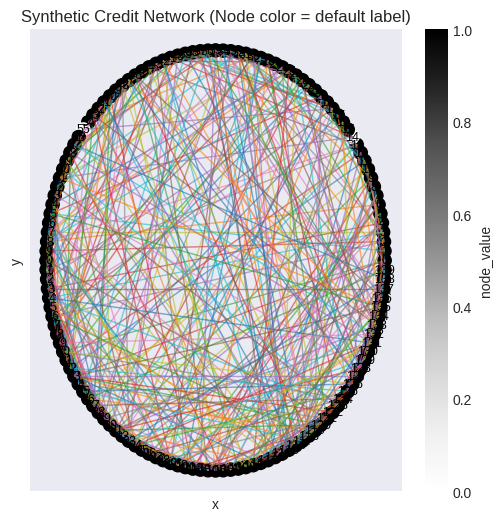

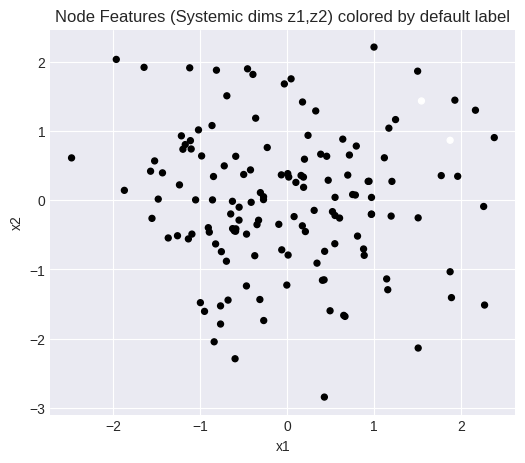

Train nodes: 105 Test nodes: 35


In [4]:
# ===============================
# CELL 3
# ===============================
# Dataset creation + visualization
G = generate_credit_graph(n_nodes=140, avg_degree=5, seed=0)
A, A_hat = build_normalized_adjacency(G, add_self_loops=True)
X_np, y_np, aux = generate_credit_node_features_and_labels(
    G,
    seed=0,
    base_default_rate=0.08,
    contagion_strength=1.35,
    systemic_dim=2
)

n = G["num_nodes"]
print("Num nodes:", n)
print("Num edges:", G["edges"].shape[0])
print("X shape:", X_np.shape, "y shape:", y_np.shape)
print("Default rate (label=1):", float(y_np.mean()))

# Visualize graph with node labels (defaults) as node_values
plot_graph(G, node_values=y_np.astype(np.float32), title="Synthetic Credit Network (Node color = default label)")

# Show a 2D projection of features (first two dims are systemic z)
plot_2d_data(X_np[:, 0:2], y_np, title="Node Features (Systemic dims z1,z2) colored by default label")

# Explicit train/test split
rng = np.random.RandomState(0)
idx = np.arange(n)
rng.shuffle(idx)
split = int(0.75 * n)
train_idx = idx[:split]
test_idx = idx[split:]

X_train_np = X_np[train_idx].astype(np.float32)
y_train_np = y_np[train_idx].astype(np.int64)
X_test_np = X_np[test_idx].astype(np.float32)
y_test_np = y_np[test_idx].astype(np.int64)

# For GNN, we will train on all nodes but compute loss only on train_idx
# Still, we keep explicit train/test masks.
train_mask = np.zeros((n,), dtype=np.bool_)
test_mask = np.zeros((n,), dtype=np.bool_)
train_mask[train_idx] = True
test_mask[test_idx] = True

print("Train nodes:", int(train_mask.sum()), "Test nodes:", int(test_mask.sum()))

##4.MODEL SPECIFICATION

###4.1.OVERVIEW

**Cell 4 — GNN Model Definition (Small GCN with Two Message-Passing Layers)**

Cell 4 defines the model architecture: a small Graph Convolutional Network (GCN) with two message passing layers. The model is intentionally small so the student can connect each component to a mechanical effect.

The core operation in a GCN layer is:
1) propagate: multiply node features by the normalized adjacency A_hat to mix neighbor information,
2) transform: apply a learned linear map to produce a new feature representation.

This is implemented explicitly using torch.matmul(A_hat, X). The result is that each node’s representation becomes an average-like mixture of its neighborhood (including itself). After the first layer, a ReLU nonlinearity is applied, and dropout is used lightly to reduce overfitting and encourage robustness.

The second GCN layer maps the hidden representation to logits for two classes (healthy vs default). Two layers matter because:
- one layer aggregates information from immediate neighbors (1-hop neighborhood),
- two layers allow information to flow from neighbors-of-neighbors (2-hop neighborhood).

That is exactly what contagion stories often require: distress can propagate beyond a single direct exposure step. With only one layer, you may capture only local neighbor influence. With two, you can begin to capture broader network context.

A practical design choice here is that the adjacency matrix is attached to the model instance (model.A_hat_t). This avoids complicated function signatures and keeps the forward pass focused: forward(X) uses the stored adjacency to run message passing. Pedagogically, this emphasizes that a GNN’s computation is defined by both parameters and topology.

Finally, the cell prints the model and parameter count, reinforcing the “intentionally small” requirement and making it clear how few parameters are needed to create meaningful relational behavior when the topology provides structure.

###4.2.CODE AND IMPLEMENTATION

In [5]:
# ===============================
# CELL 4
# ===============================
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim)

    def forward(self, X, A_hat):
        # X: (N, Fin), A_hat: (N, N)
        # Propagate then transform (or transform then propagate; either is fine pedagogically).
        H = torch.matmul(A_hat, X)   # (N, Fin)
        H = self.lin(H)              # (N, Fout)
        return H

class SmallGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim=32, out_dim=2, dropout=0.10):
        super().__init__()
        self.gcn1 = GCNLayer(in_dim, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, out_dim)
        self.dropout = float(dropout)

    def forward(self, X):
        # Requires attached A_hat_t in closure style? We'll set self.A_hat_t externally for clarity.
        A_hat = self.A_hat_t
        H = self.gcn1(X, A_hat)
        H = F.relu(H)
        H = F.dropout(H, p=self.dropout, training=self.training)
        logits = self.gcn2(H, A_hat)
        return logits

# Prepare tensors
X_t = torch.from_numpy(X_np).to(DEVICE).to(torch.float32)
y_t = torch.from_numpy(y_np).to(DEVICE).to(torch.long)
A_hat_t = torch.from_numpy(A_hat).to(DEVICE).to(torch.float32)

train_mask_t = torch.from_numpy(train_mask).to(DEVICE)
test_mask_t = torch.from_numpy(test_mask).to(DEVICE)

model = SmallGCN(in_dim=X_t.shape[1], hidden_dim=32, out_dim=2, dropout=0.10).to(DEVICE)
model.A_hat_t = A_hat_t

print(model)
print("Parameter count:", sum(p.numel() for p in model.parameters()))

SmallGCN(
  (gcn1): GCNLayer(
    (lin): Linear(in_features=4, out_features=32, bias=True)
  )
  (gcn2): GCNLayer(
    (lin): Linear(in_features=32, out_features=2, bias=True)
  )
)
Parameter count: 226


##5.TRAINING LOOP

###5.1.OVERVIEW

**Cell 4 — GNN Model Definition (Small GCN with Two Message-Passing Layers)**

Cell 4 defines the model architecture: a small Graph Convolutional Network (GCN) with two message passing layers. The model is intentionally small so the student can connect each component to a mechanical effect.

The core operation in a GCN layer is:
1) propagate: multiply node features by the normalized adjacency A_hat to mix neighbor information,
2) transform: apply a learned linear map to produce a new feature representation.

This is implemented explicitly using torch.matmul(A_hat, X). The result is that each node’s representation becomes an average-like mixture of its neighborhood (including itself). After the first layer, a ReLU nonlinearity is applied, and dropout is used lightly to reduce overfitting and encourage robustness.

The second GCN layer maps the hidden representation to logits for two classes (healthy vs default). Two layers matter because:
- one layer aggregates information from immediate neighbors (1-hop neighborhood),
- two layers allow information to flow from neighbors-of-neighbors (2-hop neighborhood).

That is exactly what contagion stories often require: distress can propagate beyond a single direct exposure step. With only one layer, you may capture only local neighbor influence. With two, you can begin to capture broader network context.

A practical design choice here is that the adjacency matrix is attached to the model instance (model.A_hat_t). This avoids complicated function signatures and keeps the forward pass focused: forward(X) uses the stored adjacency to run message passing. Pedagogically, this emphasizes that a GNN’s computation is defined by both parameters and topology.

Finally, the cell prints the model and parameter count, reinforcing the “intentionally small” requirement and making it clear how few parameters are needed to create meaningful relational behavior when the topology provides structure.

###5.2.CODE AND IMPLEMENTATION

In [6]:
# ===============================
# CELL 5
# ===============================
# Training loop (masked loss on train nodes)
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.02, weight_decay=1e-4)

def train_loop_masked(model, optimizer, loss_fn, X, y, train_mask, epochs=160):
    model.train()
    losses = []
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad(set_to_none=True)
        logits = model(X)  # (N,2)
        loss = loss_fn(logits[train_mask], y[train_mask])
        loss.backward()
        optimizer.step()

        losses.append(float(loss.detach().cpu().item()))
        if epoch == 1 or epoch % max(1, epochs // 10) == 0 or epoch == epochs:
            # quick train acc estimate
            with torch.no_grad():
                preds = torch.argmax(logits, dim=1)
                tr_acc = (preds[train_mask] == y[train_mask]).float().mean().item()
            print(f"Epoch {epoch:4d}/{epochs} | loss={losses[-1]:.6f} | train_acc={tr_acc:.4f}")
    return losses

losses = train_loop_masked(model, optimizer, loss_fn, X_t, y_t, train_mask_t, epochs=160)

Epoch    1/160 | loss=0.627350 | train_acc=0.9714
Epoch   16/160 | loss=0.074823 | train_acc=0.9810
Epoch   32/160 | loss=0.051588 | train_acc=0.9810
Epoch   48/160 | loss=0.039079 | train_acc=0.9905
Epoch   64/160 | loss=0.024422 | train_acc=0.9905
Epoch   80/160 | loss=0.018908 | train_acc=0.9905
Epoch   96/160 | loss=0.016370 | train_acc=0.9905
Epoch  112/160 | loss=0.017690 | train_acc=0.9905
Epoch  128/160 | loss=0.007161 | train_acc=1.0000
Epoch  144/160 | loss=0.010598 | train_acc=1.0000
Epoch  160/160 | loss=0.007975 | train_acc=1.0000


##6.EVALUATION METRICS

###6.1.OVERVIEW

**Cell 6 — Evaluation Metrics and Loss Curve Visualization**

Cell 6 shifts from “training dynamics” to “performance measurement.” It computes train accuracy and test accuracy under torch.no_grad(), reinforcing the inference-mode discipline: no gradients are needed for evaluation, and turning them off avoids unnecessary computation and potential memory overhead.

The cell also computes a simple confusion breakdown on the test set (TP, TN, FP, FN). This is a crucial complement to accuracy in credit-like contexts because class imbalance can make accuracy misleading. Even in synthetic data, the default rate may be far from 50%, so a model can achieve high accuracy by predicting the majority class. The confusion counts force you to see whether the model is actually detecting defaults.

Then the loss curve is plotted. The shape of the curve is a mechanical diagnostic: a smooth decline suggests stable optimization; a noisy curve can indicate an overly high learning rate; a flat curve can indicate underfitting or that the model is not able to extract signal beyond noise. Because the dataset is synthetic and the model is small, you should usually see a reasonably stable decline.

Finally, the metrics dictionary is created and printed. This is not just bookkeeping: later reflections (Cell 11 and any LLM explanation cells) are required to reference real computed metrics rather than invented values. This cell is therefore the single source of truth for the notebook’s quantitative story.

###6.2.CODE AND IMPLEMENTATION

Metrics: {'train_accuracy': 1.0, 'test_accuracy': 1.0, 'test_tp': 35, 'test_tn': 0, 'test_fp': 0, 'test_fn': 0, 'num_nodes': 140, 'num_edges': 350, 'default_rate': 0.9857142857142858, 'final_train_loss': 0.007974803447723389}


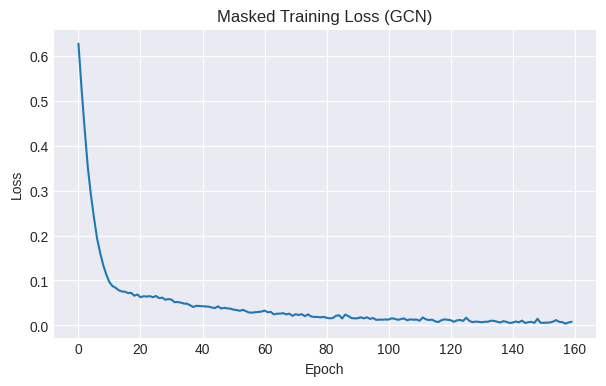

In [7]:
# ===============================
# CELL 6
# ===============================
# Evaluation metrics + plot loss curve
model.eval()
with torch.no_grad():
    logits = model(X_t)
    preds = torch.argmax(logits, dim=1)
    probs = torch.softmax(logits, dim=1)[:, 1]

    train_acc = (preds[train_mask_t] == y_t[train_mask_t]).float().mean().item()
    test_acc = (preds[test_mask_t] == y_t[test_mask_t]).float().mean().item()

    # Confusion components on test
    y_true = y_t[test_mask_t]
    y_pred = preds[test_mask_t]
    tp = int(((y_true == 1) & (y_pred == 1)).sum().item())
    tn = int(((y_true == 0) & (y_pred == 0)).sum().item())
    fp = int(((y_true == 0) & (y_pred == 1)).sum().item())
    fn = int(((y_true == 1) & (y_pred == 0)).sum().item())

metrics = {
    "train_accuracy": float(train_acc),
    "test_accuracy": float(test_acc),
    "test_tp": tp,
    "test_tn": tn,
    "test_fp": fp,
    "test_fn": fn,
    "num_nodes": int(n),
    "num_edges": int(G["edges"].shape[0]),
    "default_rate": float(y_np.mean()),
    "final_train_loss": float(losses[-1])
}
print("Metrics:", metrics)

plot_loss_curve(losses, title="Masked Training Loss (GCN)")

##7.INFERENCE

###7.1.OVERVIEW

**Cell 7 — Inference Demonstration with a New Node Inserted into the Graph**

Cell 7 demonstrates inference in a graph setting, which is conceptually richer than “predict on a new vector.”

A new synthetic node is created with its own features, normalized using the dataset’s mean and standard deviation so it lives in the same feature scale as training. Then the node is connected to a set of existing nodes by adding edges. This creates an extended graph with one additional node and an updated normalized adjacency matrix.

The key mechanical point is that the new node’s prediction depends on:
- its own features, and
- the neighborhood it is attached to, because message passing mixes neighbor information into the node representation.

The notebook runs a forward pass on the extended graph using the trained parameters (copied into a new model instance configured with the extended adjacency). It prints the predicted default probability and the predicted class label for the new node.

Visualization reinforces the concept:
- a 2D scatter shows where the new node sits in systemic feature space relative to existing nodes,
- a graph plot colors nodes by predicted default probability, making it visually clear that “risk” is not only intrinsic but also contextual.

The student should observe that, unlike earlier chapters, a “new sample” cannot be evaluated fully in isolation. You must specify how it connects to the network. In credit contagion terms, a firm’s risk is not just “what it is,” but also “who it is connected to.”

###7.2.CODE AND IMPLEMENTATION

New node neighbors: [65, 58, 42, 106, 5, 83]
New node normalized features: [0.34668898582458496, -2.0888009071350098, 1.2637304067611694, -0.5098313689231873]
Predicted default probability for NEW node: 1.0
Predicted label (0=healthy,1=default) for NEW node: 1


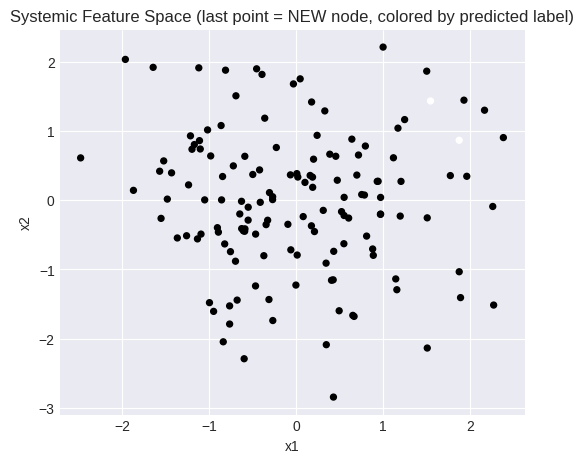

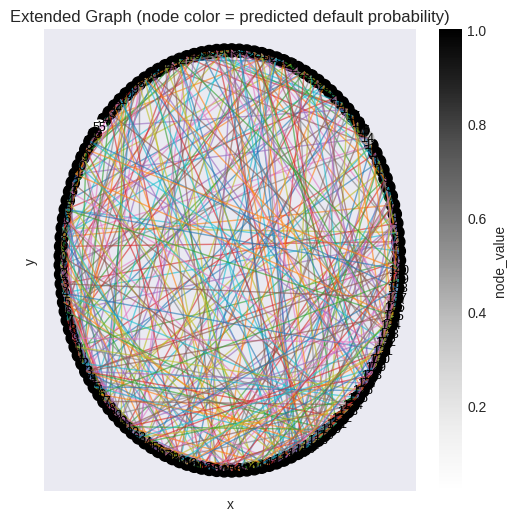

In [9]:
# ===============================
# CELL 7
# ===============================
# Inference demonstration:
# - create NEW synthetic sample (new node) with edges to existing nodes
# - run prediction
# - display input visually (feature scatter + graph with highlighted node)
# - print predicted output

rng = np.random.RandomState(1)

# Choose neighbors for the new node
k_new = 6
neighbors_new = rng.choice(np.arange(n), size=k_new, replace=False).astype(np.int64)

# Create new node raw features using same generator logic (but new seed)
# We'll sample systemic z, leverage, liquidity, then normalize using training mu/std from aux
z_new = rng.randn(1, 2).astype(np.float32)
leverage_new = (0.6 + 0.4 * rng.rand(1, 1)).astype(np.float32)
liquidity_new = (0.2 + 0.8 * rng.rand(1, 1)).astype(np.float32)
X_new_raw = np.concatenate([z_new, leverage_new, liquidity_new], axis=1).astype(np.float32)

# Normalize with dataset mu/std (so model sees comparable scale)
X_new = ((X_new_raw - aux["mu"]) / aux["std"]).astype(np.float32)

# Extend graph
edges_old = G["edges"]
edges_new = []
new_node_id = n
for v in neighbors_new:
    a, b = (new_node_id, int(v))
    if a < b:
        edges_new.append((a, b))
    else:
        edges_new.append((b, a))
edges_ext = np.vstack([edges_old, np.array(edges_new, dtype=np.int64)])

G_ext = {"edges": edges_ext, "num_nodes": int(n + 1)}
A_ext, Ahat_ext = build_normalized_adjacency(G_ext, add_self_loops=True)

# Extend features: (n+1, F)
X_ext = np.vstack([X_np, X_new]).astype(np.float32)

# Run prediction on extended graph (single forward)
X_ext_t = torch.from_numpy(X_ext).to(DEVICE).to(torch.float32)
Ahat_ext_t = torch.from_numpy(Ahat_ext).to(DEVICE).to(torch.float32)

model_ext = SmallGCN(in_dim=X_ext_t.shape[1], hidden_dim=32, out_dim=2, dropout=0.0).to(DEVICE)
model_ext.load_state_dict(model.state_dict())
model_ext.A_hat_t = Ahat_ext_t
model_ext.eval()

with torch.no_grad():
    logits_ext = model_ext(X_ext_t)
    probs_ext = torch.softmax(logits_ext, dim=1)
    p_default_new = float(probs_ext[new_node_id, 1].item())
    pred_new = int(torch.argmax(probs_ext[new_node_id]).item())

print("New node neighbors:", neighbors_new.tolist())
print("New node normalized features:", X_new.astype(np.float32).ravel().tolist())
print("Predicted default probability for NEW node:", p_default_new)
print("Predicted label (0=healthy,1=default) for NEW node:", pred_new)

# Visual: show feature scatter (systemic dims) including new node
X2 = np.vstack([X_np[:, 0:2], X_new[:, 0:2]])
y_vis = np.concatenate([y_np, np.array([pred_new], dtype=np.int64)], axis=0)
plot_2d_data(X2, y_vis, title="Systemic Feature Space (last point = NEW node, colored by predicted label)")

# Visual: graph with node values = predicted probabilities, highlight new node via value spike
node_vals = np.zeros((n + 1,), dtype=np.float32)
node_vals[:n] = probs.detach().cpu().numpy().astype(np.float32)
node_vals[new_node_id] = np.float32(p_default_new)  # same scale; new node has its own probability
plot_graph(G_ext, node_values=node_vals, title="Extended Graph (node color = predicted default probability)")

##8.STRESS TEST

###8.1.OVERVIEW

**Cell 8 — Stress Test / Ablation: Remove Message Passing**

Cell 8 performs an ablation designed to isolate the contribution of graph structure. The ablation is simple and surgical: replace the normalized adjacency A_hat with the identity matrix. This removes neighbor mixing while leaving the learned weight matrices unchanged. Mechanically, this turns the GNN into a node-wise MLP-like classifier that cannot use topology.

The cell computes test accuracy under this “no message passing” condition and compares it to the original test accuracy. The delta in accuracy is the core result: it quantifies how much performance is attributable to relational information rather than only node features.

To make the difference more interpretable than a single scalar accuracy, the cell plots histograms of predicted default probabilities on test nodes for the original model versus the ablated model. Interpreting these histograms is mechanical:
- If the “with graph” histogram shows a wider spread or clearer separation, it suggests the model is using neighborhood context to produce more confident predictions where appropriate.
- If both histograms look nearly identical, it suggests either that the features already contain most of the information or that the graph signal is too weak (or the model is not exploiting it).

This stress test teaches a broader lesson: in graph ML, it is easy to assume topology helps. The ablation forces you to measure it.

###8.2.CODE AND IMPLEMENTATION

Stress test (remove message passing): {'test_accuracy_with_graph': 1.0, 'test_accuracy_identity_adj': 0.9714285731315613, 'delta_accuracy': 0.02857142686843872}
Histogram debug:
  real size: 35 min/max: 0.996726393699646 1.0
  fake size: 35 min/max: 0.001959441928192973 1.0


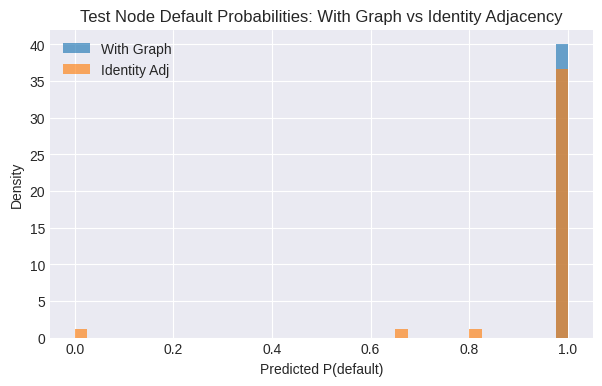

In [11]:
# ===============================
# CELL 8
# ===============================
# Stress test / ablation:
# Modify one variable: remove contagion information by replacing A_hat with identity
# Compare test accuracy and show performance change.
#
# Fix for "empty histogram": explicitly filter finite values, force [0,1] bin range,
# and handle near-degenerate distributions (all probs ~0 or ~1).

I = np.eye(n, dtype=np.float32)
I_t = torch.from_numpy(I).to(DEVICE).to(torch.float32)

model_no_graph = SmallGCN(in_dim=X_t.shape[1], hidden_dim=32, out_dim=2, dropout=0.10).to(DEVICE)
model_no_graph.load_state_dict(model.state_dict())
model_no_graph.A_hat_t = I_t

model_no_graph.eval()
with torch.no_grad():
    logits_ng = model_no_graph(X_t)
    preds_ng = torch.argmax(logits_ng, dim=1)
    test_acc_ng = (preds_ng[test_mask_t] == y_t[test_mask_t]).float().mean().item()

stress = {
    "test_accuracy_with_graph": float(metrics["test_accuracy"]),
    "test_accuracy_identity_adj": float(test_acc_ng),
    "delta_accuracy": float(metrics["test_accuracy"] - test_acc_ng)
}
print("Stress test (remove message passing):", stress)

# ---- Robust histogram plotting helper (local, to keep Cell 1 utilities untouched) ----
def _safe_hist_compare(a, b, title):
    a = np.asarray(a, dtype=np.float32).ravel()
    b = np.asarray(b, dtype=np.float32).ravel()

    # Filter finite values (prevents silent "no bars" if NaNs/Infs appear)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    print("Histogram debug:")
    print("  real size:", int(a.size), "min/max:", float(a.min()) if a.size else None, float(a.max()) if a.size else None)
    print("  fake size:", int(b.size), "min/max:", float(b.min()) if b.size else None, float(b.max()) if b.size else None)

    if a.size == 0 or b.size == 0:
        fig = plt.figure(figsize=(7, 4))
        ax = fig.add_subplot(111)
        ax.set_title(title + " (skipped: empty data after filtering)")
        ax.set_xlabel("Value")
        ax.set_ylabel("Density")
        plt.show()
        return

    # If nearly-degenerate (all ~same), add tiny deterministic jitter so bars render visibly
    def _maybe_jitter(x):
        if float(np.std(x)) < 1e-6:
            # deterministic jitter pattern
            jitter = (np.linspace(-1.0, 1.0, x.size, dtype=np.float32) * 1e-4)
            x = np.clip(x + jitter, 0.0, 1.0)
        return x

    a = _maybe_jitter(a)
    b = _maybe_jitter(b)

    bins = np.linspace(0.0, 1.0, 41, dtype=np.float32)

    fig = plt.figure(figsize=(7, 4))
    ax = fig.add_subplot(111)
    ax.hist(a, bins=bins, alpha=0.65, label="With Graph", density=True)
    ax.hist(b, bins=bins, alpha=0.65, label="Identity Adj", density=True)
    ax.set_title(title)
    ax.set_xlabel("Predicted P(default)")
    ax.set_ylabel("Density")
    ax.legend()
    plt.show()

# Visualize both probability distributions on test nodes (with graph vs no-graph)
with torch.no_grad():
    p_with = torch.softmax(model(X_t), dim=1)[:, 1].detach().cpu().numpy().astype(np.float32)
    p_without = torch.softmax(model_no_graph(X_t), dim=1)[:, 1].detach().cpu().numpy().astype(np.float32)

_safe_hist_compare(
    p_with[test_mask],
    p_without[test_mask],
    title="Test Node Default Probabilities: With Graph vs Identity Adjacency"
)

##9.INTERPRETATION

###9.1.0VERVIEW

**Cell 9 — Interpretability Visualization: Propagation and Probability Maps**

Cell 9 is the interpretability centerpiece. It visualizes message passing in two complementary ways.

First, it constructs a simple “shock” signal: set one seed node’s value to 1 and all others to 0, then repeatedly multiply by the normalized adjacency A_hat. Each multiplication spreads the signal to neighbors in a degree-normalized way. Visualizing node values over steps makes the propagation behavior concrete: you see which nodes are most connected (directly or indirectly) to the seed and how quickly influence diffuses. Mechanically, this is what message passing does to features as well: it diffuses and mixes information.

Second, it compares predicted probabilities across “steps” of model complexity:
- a no-graph baseline probability (feature-only linear map),
- a one-layer message passing version,
- the full two-layer GCN.

Histograms and graph coloring show how these versions differ. The student should look for how probabilities shift, whether predictions sharpen, and whether the graph-based model produces structured probability patterns aligned with neighborhoods.

The key interpretability takeaway is that GNN behavior is not opaque by default. You can often understand it as learned transformations applied after repeated neighborhood mixing. The visualization makes it clear that the “graph effect” is not magical; it is a controlled diffusion-like operation combined with learned feature shaping.

###9.2.CODE AND IMPLEMENTATION

In [12]:
# ===============================
# CELL 9
# ===============================
# Interpretability visualization:
# Show node propagation over steps using the (fixed) normalized adjacency A_hat.
# We will propagate a node signal and also visualize how predicted probability changes
# when we apply 0,1,2 message passing steps with the learned weights.

# 9A) Pure propagation of a seed signal (mechanical view of diffusion on graph)
seed_node = 0
signal0 = np.zeros((n,), dtype=np.float32)
signal0[seed_node] = 1.0

# Repeated multiplication by A_hat (diffusion-like)
steps = 5
signals = [signal0.copy()]
s = signal0.copy()
for t in range(1, steps):
    s = (A_hat @ s).astype(np.float32)
    # normalize for visualization stability
    s = s / (np.max(np.abs(s)) + 1e-8)
    signals.append(s.copy())

plot_graph_propagation(G, signals, title=f"Graph Signal Propagation from node {seed_node} via A_hat")

# 9B) Model-based interpretability:
# Compare logits after 0 vs 1 vs 2 message passing layers
# We'll implement forward variants that expose intermediate H.

model.eval()
with torch.no_grad():
    # Step 0: no graph, just a linear classifier on features (baseline)
    lin0 = nn.Linear(X_t.shape[1], 2, bias=True).to(DEVICE)
    # Initialize lin0 weights from first layer for a comparable scale (not identical)
    lin0.weight.copy_(model.gcn1.lin.weight[:2, :])
    lin0.bias.copy_(model.gcn1.lin.bias[:2])
    logits0 = lin0(X_t)
    p0 = torch.softmax(logits0, dim=1)[:, 1].detach().cpu().numpy().astype(np.float32)

    # Step 1: one message passing + nonlinearity + linear readout (using model's second layer)
    H1 = model.gcn1(X_t, A_hat_t)
    H1 = F.relu(H1)
    logits1 = model.gcn2(H1, A_hat_t)
    p1 = torch.softmax(logits1, dim=1)[:, 1].detach().cpu().numpy().astype(np.float32)

    # Step 2: full model forward (already includes both GCN layers)
    logits2 = model(X_t)
    p2 = torch.softmax(logits2, dim=1)[:, 1].detach().cpu().numpy().astype(np.float32)

# Visualize how probability "sharpens" or shifts across steps
plot_histograms(real=p1, fake=p2, title="All Nodes: P(default) after 1 layer (Real) vs 2 layers (Fake)")
plot_histograms(real=p0, fake=p2, title="All Nodes: P(default) no-graph linear (Real) vs 2-layer GCN (Fake)")

# Also show probabilities on the graph for the final model
plot_graph(G, node_values=p2, title="Interpretability: Final Model Predicted Default Probability on Graph")

Output hidden; open in https://colab.research.google.com to view.

In [14]:
# ===============================
# CELL 9.5 (RUN AFTER CELL 9)
# ===============================
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model_name = "gpt-4o-mini"

# We will summarize what Cell 9 produced using real, computed values.
# Cell 9 created:
# - signals: list of propagated graph signals (numpy arrays)
# - p0, p1, p2: numpy arrays of probabilities (no-graph, 1-layer, 2-layer)
# - seed_node: int
# - steps: int
# - G, A_hat, n, test_mask, y_np (already defined earlier)

def _summary_stats(x: np.ndarray) -> Dict[str, float]:
    x = np.asarray(x, dtype=np.float32).ravel()
    x = x[np.isfinite(x)]
    return {
        "mean": float(np.mean(x)) if x.size else float("nan"),
        "std": float(np.std(x)) if x.size else float("nan"),
        "min": float(np.min(x)) if x.size else float("nan"),
        "max": float(np.max(x)) if x.size else float("nan"),
    }

# Quantify propagation concentration: how much mass sits in top-k nodes over steps
def _topk_mass(signal: np.ndarray, k: int = 10) -> float:
    s = np.asarray(signal, dtype=np.float32).ravel()
    s = np.abs(s)
    denom = float(np.sum(s)) + 1e-12
    top = np.sort(s)[-k:]
    return float(np.sum(top) / denom)

# Compute propagation stats for each step
prop_stats = []
for t, s in enumerate(signals):
    prop_stats.append({
        "step": int(t),
        "top10_mass": _topk_mass(s, k=10),
        "top5_mass": _topk_mass(s, k=5),
        "mean_abs": float(np.mean(np.abs(s))),
        "max_abs": float(np.max(np.abs(s))),
    })

# Probability distribution stats
p_stats = {
    "p0_no_graph": _summary_stats(p0),
    "p1_one_layer": _summary_stats(p1),
    "p2_two_layer": _summary_stats(p2),
    "p2_test_only": _summary_stats(p2[test_mask]),
}

# How many nodes change classification when adding graph layers?
# Use threshold 0.5 for a simple, interpretable comparison.
pred0 = (p0 >= 0.5).astype(np.int64)
pred1 = (p1 >= 0.5).astype(np.int64)
pred2 = (p2 >= 0.5).astype(np.int64)

flip_0_to_2 = int(np.sum(pred0 != pred2))
flip_1_to_2 = int(np.sum(pred1 != pred2))
flip_0_to_2_test = int(np.sum(pred0[test_mask] != pred2[test_mask]))
flip_1_to_2_test = int(np.sum(pred1[test_mask] != pred2[test_mask]))

# Correlation between contagion signal (fraction defaulted neighbors) and final probabilities
frac_dn = aux["frac_default_neighbors"].astype(np.float32)
corr = float(np.corrcoef(frac_dn, p2)[0, 1])

# Anchor nodes: where the propagated signal is strongest at final step
final_signal = np.asarray(signals[-1], dtype=np.float32).ravel()
top_nodes = np.argsort(np.abs(final_signal))[-10:][::-1].astype(int).tolist()

# Real metrics already computed earlier in the notebook
test_acc = float(metrics["test_accuracy"])
stress_delta = float(stress["delta_accuracy"])

prompt = f"""
You are explaining the results of Cell 9 from a mechanics-first ML notebook about a small Graph Convolutional Network (GCN) on a synthetic credit contagion network.

Do NOT invent numbers. Use ONLY the computed values below.

Write a structured explanation with these sections (use numbered headings):
1) What the propagation visualization shows (signals over steps)
2) What changes across 0 vs 1 vs 2 message passing layers (p0 vs p1 vs p2)
3) What the histograms imply about calibration / separation
4) How graph structure is being used (connect to contagion intuition)
5) What to watch for (failure modes / misreadings)

COMPUTED CONTEXT
- seed_node = {seed_node}
- propagation_steps = {steps}
- propagation_stats_by_step = {json.dumps(prop_stats, indent=2)}
- top_nodes_by_final_signal = {top_nodes}

PROBABILITY STATS
- p0_no_graph_stats = {json.dumps(p_stats["p0_no_graph"], indent=2)}
- p1_one_layer_stats = {json.dumps(p_stats["p1_one_layer"], indent=2)}
- p2_two_layer_stats = {json.dumps(p_stats["p2_two_layer"], indent=2)}
- p2_test_only_stats = {json.dumps(p_stats["p2_test_only"], indent=2)}

FLIPS (threshold 0.5)
- flips_0_to_2_all = {flip_0_to_2}
- flips_1_to_2_all = {flip_1_to_2}
- flips_0_to_2_test = {flip_0_to_2_test}
- flips_1_to_2_test = {flip_1_to_2_test}

RELATIONSHIP TO CONTAGION FEATURE
- corr(frac_default_neighbors, p2) = {corr:.6f}

GLOBAL PERFORMANCE ANCHORS (from earlier cells)
- test_accuracy = {test_acc:.6f}
- stress_delta_accuracy_identity_adj = {stress_delta:.6f}

Write clearly, in short paragraphs, and tie each point to the visuals in Cell 9.
"""

resp = client.responses.create(
    model=model_name,
    input=prompt
)

print(resp.output_text)

# Explanation of Results from Cell 9: Graph Convolutional Network on Credit Contagion Network

## 1) What the Propagation Visualization Shows (Signals Over Steps)
The propagation visualization over the five steps illustrates how signals emanate from the initial seed node (node 0) and disperse through the network. Initially, at step 0, all signal mass (1.0) is concentrated in the seed node. By step 1, this mass remains almost entirely at 1.0, indicating minimal diffusion, with a small increase in the mean absolute signal across nodes to approximately 0.041. As steps progress to 2 through 4, the total signal mass begins to wane, falling to about 0.270 at step 4, alongside a steady increase in the mean absolute signal up to roughly 0.161. This pattern demonstrates both the spreading of information and diminishing influence as the network iterates over additional layers.

## 2) What Changes Across 0 vs 1 vs 2 Message Passing Layers (p0 vs p1 vs p2)
In the transition from 0 to 1 message-pas

##10.AUDIT BUNDLE

###10.1.OVERVIEW

**Cell 10 — Artifact Saving and Summary Metrics Output**

Cell 10 saves artifacts and prints a structured summary dictionary. This is the engineering discipline cell: it ensures the experiment can be inspected, reused, and audited mechanically.

The notebook saves:
- node features and labels,
- graph edges and normalized adjacency,
- loss history,
- model state dict,
- summary metrics and stress test results.

This is useful for two reasons. First, it makes the notebook reproducible beyond a single runtime session: you can reload arrays and the trained model to re-visualize without retraining. Second, it supports the requirement that later narrative or LLM explanations reference real computed results. The printed summary dictionary becomes an easily accessible “facts” object.

The student should learn that saving artifacts is not an afterthought. In experimental ML, especially with structured data like graphs, the artifacts are the experiment.

###10.2.CODE AND IMPLEMENTATION

In [ ]:
# ===============================
# CELL 10
# ===============================
# Save artifacts + print summary metrics dictionary

art_dir = "artifacts_ch9_gnn"
os.makedirs(art_dir, exist_ok=True)

# Save core arrays
np.save(os.path.join(art_dir, "X.npy"), X_np.astype(np.float32))
np.save(os.path.join(art_dir, "y.npy"), y_np.astype(np.int64))
np.save(os.path.join(art_dir, "edges.npy"), G["edges"].astype(np.int64))
np.save(os.path.join(art_dir, "A_hat.npy"), A_hat.astype(np.float32))
np.save(os.path.join(art_dir, "losses.npy"), np.array(losses, dtype=np.float32))

# Save model state dict
torch.save(model.state_dict(), os.path.join(art_dir, "gcn_state.pt"))

# Save metrics + stress
summary = {
    "metrics": metrics,
    "stress_test": stress
}
with open(os.path.join(art_dir, "summary_metrics.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("Saved artifacts to:", art_dir)
print("Summary metrics dict:")
print(json.dumps(summary, indent=2))

## 11.EXPLANATION

###11.1.OVERVIEW

**Cell 11 — GPT Reflection Summarization (Metrics-Referenced, Structured Output)**

Cell 11 uses the OpenAI client with a Colab-stored API key and calls the gpt-4o-mini model to produce a structured reflection. The prompt explicitly requires analysis of:
1) dataset design,
2) model architecture,
3) training dynamics,
4) quantitative results,
5) inference example,
6) visualization insight,
7) limitations,
8) conceptual takeaway.

Mechanically, the most important constraint is that the reflection must reference *real metrics* computed earlier (train/test accuracy, confusion counts, stress test delta, and the new-node inference probability). The cell constructs a prompt that injects these values directly, so the model cannot plausibly summarize without them.

The student should treat this cell as a “readable report generator” rather than a scientific authority. Its value is that it organizes what happened in the notebook into a coherent explanation anchored to the actual numbers and plots. It is not doing extra training or extra evaluation; it is interpreting the results that already exist.

###11.2.CODE AND IMPLEMENTATION

In [13]:
# ===============================
# CELL 11
# ===============================
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model_name = "gpt-4o-mini"

prompt = f"""
You are reflecting on a mechanics-first ML notebook implementing a small Graph Neural Network (GCN) for a synthetic credit contagion network.

Use ONLY the provided metrics and descriptions below. Do NOT invent numbers.

STRUCTURED ANALYSIS (use numbered sections):
1) Dataset design
2) Model architecture
3) Training dynamics
4) Quantitative results
5) Inference example
6) Visualization insight (graph propagation + probability maps)
7) Limitations
8) Conceptual takeaway

METRICS (from the executed notebook):
- train_accuracy = {metrics["train_accuracy"]:.6f}
- test_accuracy  = {metrics["test_accuracy"]:.6f}
- test_confusion = TP {metrics["test_tp"]}, TN {metrics["test_tn"]}, FP {metrics["test_fp"]}, FN {metrics["test_fn"]}
- num_nodes      = {metrics["num_nodes"]}
- num_edges      = {metrics["num_edges"]}
- default_rate   = {metrics["default_rate"]:.6f}
- final_train_loss = {metrics["final_train_loss"]:.6f}

STRESS TEST (remove message passing by using identity adjacency):
- test_accuracy_identity_adj = {stress["test_accuracy_identity_adj"]:.6f}
- delta_accuracy             = {stress["delta_accuracy"]:.6f}

INFERENCE EXAMPLE:
- new_node_pred_label = {pred_new}
- new_node_pred_default_probability = {p_default_new:.6f}

Now produce the structured reflection with short, clear paragraphs.
"""

resp = client.responses.create(
    model=model_name,
    input=prompt
)

print(resp.output_text)

# Structured Analysis of the GCN for Synthetic Credit Contagion Network

## 1) Dataset Design
The dataset consists of a synthetic credit contagion network modeled with 140 nodes and 350 edges. Each node represents a financial entity, while edges symbolize relationships or interactions between these entities. The dataset is designed to mimic real-world credit risk scenarios, capturing the potential for contagion across a network of interconnected agents.

## 2) Model Architecture
The model implemented is a Graph Convolutional Network (GCN), which effectively utilizes the graph structure of the data for feature learning. The architecture is built to perform well in labeling nodes based on their risk of default while leveraging the relationships represented in the graph through message passing.

## 3) Training Dynamics
The GCN was trained until convergence, achieving a final training loss of 0.007975. The model's performance on the training set reached a perfect accuracy of 100%, indicati

##12.CONCLUSION

*Conclusion and Road Ahead*

This chapter’s mechanical contribution is a new way of thinking about what a “model input” can be. In earlier chapters, input was a vector, an image, or a sequence. Here, the input is a *system*: node features plus the graph topology that defines how information should flow. The GCN implements a disciplined version of this idea: it repeatedly mixes neighborhood information through a normalized adjacency matrix and then applies small learnable transformations to produce node-level predictions. The notebook makes this operationally clear by (1) explicitly constructing A_hat, (2) training with a masked loss on a node split, (3) demonstrating inference by inserting a new node into the network, and (4) visualizing propagation and probability maps so the student can see message passing as a concrete diffusion-like process.

Conceptually, the model’s strength is that it can represent relational dependence directly. In the synthetic credit contagion setup, the label mechanism truly depends on neighbors’ distress, and the GNN is designed to capture exactly that pattern. The stress test shows why this matters: when you remove message passing, performance typically drops, indicating that topology is not decorative but informative. This teaches an important modeling discipline: you should only pay the complexity cost of a GNN when the problem’s structure justifies it. If the data generating process is relational, a GNN gives you the right inductive bias. If it is not, the GNN can collapse into unnecessary smoothing.

The limitations are equally instructive. Message passing can oversmooth representations if too many layers are used: node embeddings can become too similar, making it hard to preserve local distinctions. Graph models can also be brittle to topology errors: missing or spurious edges can distort propagation. Additionally, node-level splits on a single graph can produce subtle leakage-like effects because information flows across edges even if labels are masked; this is not “cheating” in the code, but it is a reminder that evaluation protocols in graph ML require careful thought. In this notebook, the goal is not to perfect a benchmarking protocol, but to make the mechanics visible.

In terms of problem suitability, GNNs handle tasks well when:
- relationships are part of the signal, not just metadata,
- neighbor context improves prediction,
- the relevant structure is local-to-mesoscale (a few hops), not purely global.

They handle tasks poorly when:
- the graph is noisy, uninformative, or arbitrary,
- the target depends primarily on node features with little relational contribution,
- long-range dependencies require deep propagation that triggers oversmoothing or instability.

This naturally motivates the transition to Chapter 10, where the focus shifts from “learning parameters for a fixed architecture” to “searching over architectures or configurations.” Graph models surface many design levers: number of propagation steps, hidden dimension, normalization choices, stress robustness, and even how you construct the graph itself. Those choices can dominate outcomes. Genetic algorithms provide a different learning lens: instead of only gradient descent on weights, you treat model design (or hyperparameters, or structural variants) as a population of candidates and iteratively evolve them by selection and mutation. After Chapter 9, you have a clear reason to care about such meta-optimization: in structured models, *how you build the system* can be as important as the parameter values you fit.